In [1]:
import tensorflow as tf 
import numpy as np 
import matplotlib.pyplot as plt 
import os 
import re 
import shutil 
import string 

In [2]:
url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz" 
dataset = tf.keras.utils.get_file("aclImdb_v1", url, untar=True, cache_dir='.', cache_subdir='' ) 
dataset_dir = os.path.join(os.path.dirname(dataset),"aclImdb_v1",'aclImdb') 

In [3]:
os.listdir(dataset_dir) 

['.ipynb_checkpoints', 'imdb.vocab', 'imdbEr.txt', 'README', 'test', 'train']

In [4]:
train_dir = os.path.join(dataset_dir,"train") 
os.listdir(train_dir)

['labeledBow.feat',
 'neg',
 'pos',
 'unsup',
 'unsupBow.feat',
 'urls_neg.txt',
 'urls_pos.txt',
 'urls_unsup.txt']

In [5]:
train_dir = os.path.join(dataset_dir,"train") 
os.listdir(train_dir) 

['labeledBow.feat',
 'neg',
 'pos',
 'unsup',
 'unsupBow.feat',
 'urls_neg.txt',
 'urls_pos.txt',
 'urls_unsup.txt']

In [9]:
unsup_path = os.path.join(train_dir, "unsup")
if os.path.exists(unsup_path):
    shutil.rmtree(unsup_path) 
 
batch_size = 128 
seed = 42 
raw_train_ds = tf.keras.utils.text_dataset_from_directory( 
    'aclImdb_v1/aclImdb/train', 
    batch_size=batch_size, 
    validation_split=0.2, 
    subset='training', 
    seed=seed
) 

Found 25000 files belonging to 2 classes.
Using 20000 files for training.


In [11]:
raw_val_ds = tf.keras.utils.text_dataset_from_directory( 
    'aclImdb_v1/aclImdb/train', 
    batch_size=batch_size, 
    validation_split=0.2, 
    subset='validation', 
    seed=seed
) 

Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


In [12]:
test_dir = os.path.join(dataset_dir,"test") 
os.listdir(test_dir) 

['labeledBow.feat', 'neg', 'pos', 'urls_neg.txt', 'urls_pos.txt']

In [14]:
raw_test_ds = tf.keras.utils.text_dataset_from_directory( 
    'aclImdb_v1/aclImdb/test', 
    batch_size=batch_size
)

Found 25000 files belonging to 2 classes.


In [15]:
AUTOTUNE = tf.data.AUTOTUNE 
 
train_ds = raw_train_ds.cache().prefetch(buffer_size=AUTOTUNE) 
val_ds = raw_val_ds.cache().prefetch(buffer_size=AUTOTUNE) 
test_ds = raw_test_ds.cache().prefetch(buffer_size=AUTOTUNE) 

In [17]:
def custom_standardization(input_data): 
    lowercase = tf.strings.lower(input_data) 
    stripped_html = tf.strings.regex_replace(lowercase, '<br />', ' ') 
    return tf.strings.regex_replace( 
        stripped_html, 
        f'[{re.escape(string.punctuation)}]', 
        '' 
    ) 

In [18]:
max_features = 10000 
sequence_length = 250 
 
vectorize_layer = tf.keras.layers.TextVectorization( 
standardize=custom_standardization, 
max_tokens=max_features, 
output_mode='int', 
output_sequence_length=sequence_length) 
vectorize_layer.adapt(raw_train_ds.map(lambda x, y: x))

In [19]:
model = tf.keras.Sequential([ 
    vectorize_layer, 
    tf.keras.layers.Embedding( 
    input_dim=len(vectorize_layer.get_vocabulary()), 
    output_dim=64, 
    mask_zero=True), 
 
tf.keras.layers.Bidirectional(
    tf.keras.layers.LSTM(64,return_sequences=True)), 
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)), 
    tf.keras.layers.Dense(64, activation='relu'), 
    tf.keras.layers.Dense(1) 
]) 
 
model.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True), 
    optimizer=tf.keras.optimizers.Adam(1e-4), 
    metrics=['accuracy']) 
 
model.summary() 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ text_vectorization                   │ ?                           │     0 (unbuilt) │
│ (TextVectorization)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model.fit(
    train_ds, 
    epochs=10, 
    validation_data=val_ds, 
    validation_steps=30) 

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 220s 978ms/step - accuracy: 0.5019 - loss: 0.6878 - val_accuracy: 0.4927 - val_loss: 0.6333
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 133s 846ms/step - accuracy: 0.8101 - loss: 0.4026 - val_accuracy: 0.8401 - val_loss: 0.3340
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 129s 823ms/step - accuracy: 0.8899 - loss: 0.2672 - val_accuracy: 0.8674 - val_loss: 0.3134
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 133s 845ms/step - accuracy: 0.9176 - loss: 0.2130 - val_accuracy: 0.8732 - val_loss: 0.3244
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 133s 844ms/step - accuracy: 0.9276 - loss: 0.1949 - val_accuracy: 0.8552 - val_loss: 0.3480
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 133s 850ms/step - accuracy: 0.9182 - loss: 0.2026 - val_accuracy: 0.8388 - val_loss: 0.3333
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 135s 859ms/step - accuracy: 0.9222 - loss: 0.1996 - val_accuracy: 0.8693 - val_loss: 0.3170
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 138s 879ms/step - accuracy: 0.9245 -

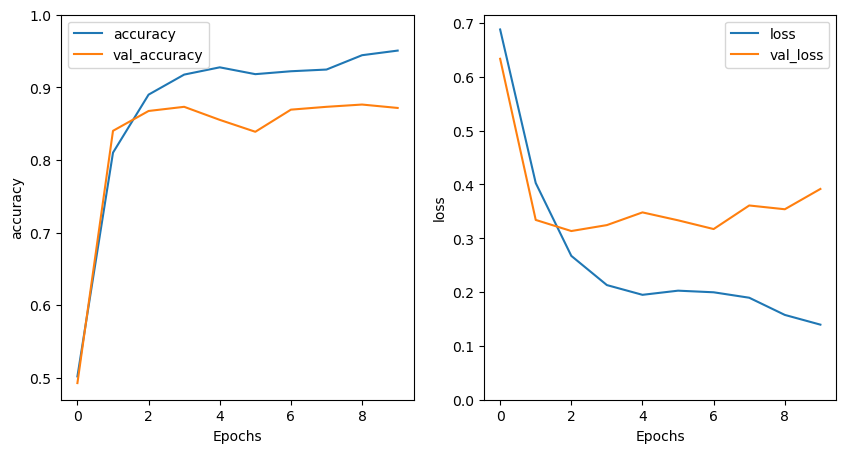

In [21]:
def plot_graphs(history, metric): 
    plt.plot(history.history[metric]) 
    plt.plot(history.history['val_'+metric], '') 
    plt.xlabel("Epochs") 
    plt.ylabel(metric) 
    plt.legend([metric, 'val_'+metric]) 
 
plt.figure(figsize=(10, 5)) 
plt.subplot(1, 2, 1) 
plot_graphs(history, 'accuracy') 
plt.ylim(None, 1) 
plt.subplot(1, 2, 2) 
plot_graphs(history, 'loss') 
plt.ylim(0, None) 
plt.show() 

In [22]:
test_loss, test_acc = model.evaluate(test_ds) 
print('Test Loss:', test_loss) 
print('Test Accuracy:', test_acc) 

196/196 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.8567 - loss: 0.4206
Test Loss: 0.42055004835128784
Test Accuracy: 0.856719970703125


In [27]:

samples = [ 
    'The movie was awesome, wonderful and amazing.', 
    "The Movies is the bad and waste of time." 
]

predictions = model.predict(samples) 
print(predictions)

ValueError: Unrecognized data type: x=['The movie was awesome, wonderful and amazing.', 'The Movies is the bad and waste of time.'] (of type <class 'list'>)